<a href="https://colab.research.google.com/github/alissongurgel8/Impact1/blob/main/Impact2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Exploratória de Dados

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def converter_cotahist_dataframe(caminho_arquivo):
    larguras_colunas = [
        (0, 2),    # Tipo de Registro
        (2, 10),   # Data do Pregão
        (10, 12),  # Cód BDI
        (12, 24),  # Ticker da Ação
        (24, 27),  # Tipo de Mercado
        (27, 39),  # Nome Resumido da Empresa
        (56, 69),  # Preço de Abertura
        (69, 82),  # Preço Máximo
        (82, 95),  # Preço Mínimo
        (95, 108), # Preço Médio
        (108, 121),# Preço de Fechamento
        (170, 188),# Volume Financeiro Total
        (188, 201),# Preço de Exercício (Opções)
        (201, 202),# Indicador de Correção
        (202, 210),# Data de Vencimento (Opções)
        (210, 217),# Fator de Cotação
        (217, 230),# Preço de Exercício em Pontos
        (230, 242),# Código ISIN
        (242, 245) # Num. Distribuição
    ]

    # Adicionamos os respectivos nomes no parâmetro 'names'
    nomes_colunas = [
        'tipo_registro', 'data_pregao', 'cod_bdi', 'ticker', 'tipo_mercado',
        'nome_empresa', 'preco_abertura', 'preco_maximo', 'preco_minimo',
        'preco_medio', 'preco_fechamento', 'volume',
        'preco_exercicio', 'ind_correcao', 'data_vencimento', 'fator_cotacao',
        'preco_exerc_pontos', 'codigo_isin', 'num_distribuicao'
    ]

    # Execução do read_fwf com os parâmetros explicados
    df = pd.read_fwf(
        caminho_arquivo,
        colspecs=larguras_colunas,
        names=nomes_colunas,
        skiprows=1,
        skipfooter=1,
        engine='python',
        encoding='ISO-8859-1'
    )

    # Filtragem e Limpeza basica
    df = df[df['tipo_registro'] == 1].copy()
    df.drop(columns=['tipo_registro'], inplace=True)

    # Remove espaços em branco das strings
    df['ticker'] = df['ticker'].str.strip()
    df['nome_empresa'] = df['nome_empresa'].str.strip()
    df['codigo_isin'] = df['codigo_isin'].str.strip()

    # Tratamento das colunas de data
    df['data_pregao'] = pd.to_datetime(df['data_pregao'], format='%Y%m%d')
    df['data_vencimento'] = pd.to_datetime(df['data_vencimento'], format='%Y%m%d', errors='coerce')

    # Ajuste das casas decimais (dividindo por 100), incluindo os novos campos de preço
    colunas_decimais = [
        'preco_abertura', 'preco_maximo', 'preco_minimo',
        'preco_medio', 'preco_fechamento', 'volume',
        'preco_exercicio', 'preco_exerc_pontos'
    ]
    for col in colunas_decimais:
        df[col] = df[col] / 100.0

    return df

df_b3 = converter_cotahist_dataframe("COTAHIST.A1990")

df_b3.head()

,data_pregao,cod_bdi,ticker,tipo_mercado,nome_empresa,preco_abertura,preco_maximo,preco_minimo,preco_medio,preco_fechamento,volume,preco_exercicio,ind_correcao,data_vencimento,fator_cotacao,preco_exerc_pontos,codigo_isin,num_distribuicao
0,1990-01-02,2,EAL 1,10,ACO ALTONA,30.0,30.0,30.0,30.00,30.00,5325.00,0.0,0,NaT,1000,0.0,EALTACOP,121
1,1990-01-02,2,AVI 2,10,ACOS VILL,68.0,76.0,68.0,71.88,71.00,2265206.44,0.0,0,NaT,1000,0.0,AVILACPP,149
2,1990-01-02,2,ILM 2,10,ADUBOS TREVO,20.0,20.5,20.0,20.28,20.50,2387.55,0.0,0,NaT,1000,0.0,ILMDACPP,16
3,1990-01-02,2,BAM 2,10,AGRIMISA,270.0,270.0,270.0,270.00,270.00,5400.00,0.0,0,NaT,1000,0.0,BAMGACPP,106
4,1990-01-02,2,SAG 2,10,AGROCERES,185.0,195.0,185.0,191.87,194.99,34038.70,0.0,0,NaT,1000,0.0,SAGRACPP,28


In [3]:
df_acoes = df_b3[df_b3['tipo_mercado'] == 10]

df_acoes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72205 entries, 0 to 108451
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   data_pregao         72205 non-null  datetime64[ns]
 1   cod_bdi             72205 non-null  int64         
 2   ticker              72205 non-null  object        
 3   tipo_mercado        72205 non-null  int64         
 4   nome_empresa        72205 non-null  object        
 5   preco_abertura      72205 non-null  float64       
 6   preco_maximo        72205 non-null  float64       
 7   preco_minimo        72205 non-null  float64       
 8   preco_medio         72205 non-null  float64       
 9   preco_fechamento    72205 non-null  float64       
 10  volume              72205 non-null  float64       
 11  preco_exercicio     72205 non-null  float64       
 12  ind_correcao        72205 non-null  int64         
 13  data_vencimento     0 non-null      datetime64[ns]

In [4]:
df_acoes.head()

,data_pregao,cod_bdi,ticker,tipo_mercado,nome_empresa,preco_abertura,preco_maximo,preco_minimo,preco_medio,preco_fechamento,volume,preco_exercicio,ind_correcao,data_vencimento,fator_cotacao,preco_exerc_pontos,codigo_isin,num_distribuicao
0,1990-01-02,2,EAL 1,10,ACO ALTONA,30.0,30.0,30.0,30.00,30.00,5325.00,0.0,0,NaT,1000,0.0,EALTACOP,121
1,1990-01-02,2,AVI 2,10,ACOS VILL,68.0,76.0,68.0,71.88,71.00,2265206.44,0.0,0,NaT,1000,0.0,AVILACPP,149
2,1990-01-02,2,ILM 2,10,ADUBOS TREVO,20.0,20.5,20.0,20.28,20.50,2387.55,0.0,0,NaT,1000,0.0,ILMDACPP,16
3,1990-01-02,2,BAM 2,10,AGRIMISA,270.0,270.0,270.0,270.00,270.00,5400.00,0.0,0,NaT,1000,0.0,BAMGACPP,106
4,1990-01-02,2,SAG 2,10,AGROCERES,185.0,195.0,185.0,191.87,194.99,34038.70,0.0,0,NaT,1000,0.0,SAGRACPP,28


In [5]:
df_acoes.shape

(72205, 18)

In [6]:
df_acoes.describe()

,data_pregao,cod_bdi,tipo_mercado,preco_abertura,preco_maximo,preco_minimo,preco_medio,preco_fechamento,volume,preco_exercicio,ind_correcao,data_vencimento,fator_cotacao,preco_exerc_pontos,num_distribuicao
count,72205,72205.000000,72205.0,7.220500e+04,7.220500e+04,7.220500e+04,7.220500e+04,7.220500e+04,7.220500e+04,72205.0,72205.0,0,72205.000000,72205.0,72205.000000
mean,1990-06-28 17:15:06.768229248,2.290008,10.0,2.326230e+04,2.345453e+04,2.313895e+04,2.329955e+04,2.333251e+04,3.266216e+06,0.0,0.0,NaT,996.029181,0.0,103.747178
min,1990-01-02 00:00:00,2.000000,10.0,1.000000e-02,1.000000e-02,1.000000e-02,0.000000e+00,1.000000e-02,5.000000e-02,0.0,0.0,NaT,1.000000,0.0,1.000000
25%,1990-03-12 00:00:00,2.000000,10.0,7.500000e+01,7.630000e+01,7.500000e+01,7.505000e+01,7.500000e+01,1.202200e+04,0.0,0.0,NaT,1000.000000,0.0,100.000000
50%,1990-07-06 00:00:00,2.000000,10.0,5.000000e+02,5.000100e+02,5.000000e+02,5.000000e+02,5.000000e+02,8.600000e+04,0.0,0.0,NaT,1000.000000,0.0,112.000000
75%,1990-09-26 00:00:00,2.000000,10.0,3.800010e+03,3.900000e+03,3.800000e+03,3.870000e+03,3.900000e+03,6.969400e+05,0.0,0.0,NaT,1000.000000,0.0,136.000000
max,1990-12-28 00:00:00,58.000000,10.0,3.500000e+07,3.500000e+07,3.500000e+07,3.500000e+07,3.500000e+07,1.323114e+09,0.0,0.0,NaT,1000.000000,0.0,247.000000
std,NaN,1.914663,0.0,2.974997e+05,2.978627e+05,2.972141e+05,2.975344e+05,2.975923e+05,2.161627e+07,0.0,0.0,NaN,62.858060,0.0,50.169623


In [7]:
df_acoes.isnull().sum()

,0
data_pregao,0
cod_bdi,0
ticker,0
tipo_mercado,0
nome_empresa,0
preco_abertura,0
preco_maximo,0
preco_minimo,0
preco_medio,0
preco_fechamento,0


In [8]:
# Remove a coluna data_vencimento do DataFrame
df_acoes = df_acoes.drop(columns=['data_vencimento'])

In [9]:
def deflacionar_precos_b3(df_b3):
    # 1. Puxar a série do IPCA (Código 433 do Banco Central - IPCA variação mensal %)
    url_bc = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.433/dados?formato=json"
    ipca_mensal = pd.read_json(url_bc)

    # Formatar as datas do IPCA
    ipca_mensal['data'] = pd.to_datetime(ipca_mensal['data'], format='%d/%m/%Y')
    ipca_mensal['valor'] = ipca_mensal['valor'] / 100  # Transformar porcentagem em decimal

    # Criar uma coluna de 'Ano-Mês' para facilitar o agrupamento/cruzamento
    ipca_mensal['ano_mes'] = ipca_mensal['data'].dt.to_period('M')
    df_b3['ano_mes'] = df_b3['data_pregao'].dt.to_period('M')

    # 2. Calcular o fator acumulado da inflação (trazendo o passado para o presente)
    # Vamos calcular o fator invertendo a série para acumular do presente para o passado
    ipca_mensal = ipca_mensal.sort_values('data', ascending=False)
    ipca_mensal['fator_acumulado'] = (1 + ipca_mensal['valor']).cumprod()

    # Mapear o fator acumulado de volta para o DataFrame da B3 baseado no Ano-Mês
    dicionario_inflacao = dict(zip(ipca_mensal['ano_mes'], ipca_mensal['fator_acumulado']))
    df_b3['fator_inflacao'] = df_b3['ano_mes'].map(dicionario_inflacao)

    # 3. Aplicar a correção nos preços
    # Multiplicamos o preço nominal pelo fator para descobrir o valor equivalente hoje
    df_b3['preco_fechamento_ajustado'] = df_b3['preco_fechamento'] * df_b3['fator_inflacao']

    # Remover colunas auxiliares
    df_b3.drop(columns=['ano_mes', 'fator_inflacao'], inplace=True)

    return df_b3

# --- Executando no seu DataFrame ---
df_acoes_corrigido = deflacionar_precos_b3(df_acoes)
print(df_acoes_corrigido[['data_pregao', 'ticker', 'preco_fechamento', 'preco_fechamento_ajustado']].head())

  data_pregao ticker  preco_fechamento  preco_fechamento_ajustado
0  1990-01-02  EAL 1             30.00               7.108492e+07
1  1990-01-02  AVI 2             71.00               1.682343e+08
2  1990-01-02  ILM 2             20.50               4.857470e+07
3  1990-01-02  BAM 2            270.00               6.397643e+08
4  1990-01-02  SAG 2            194.99               4.620283e+08


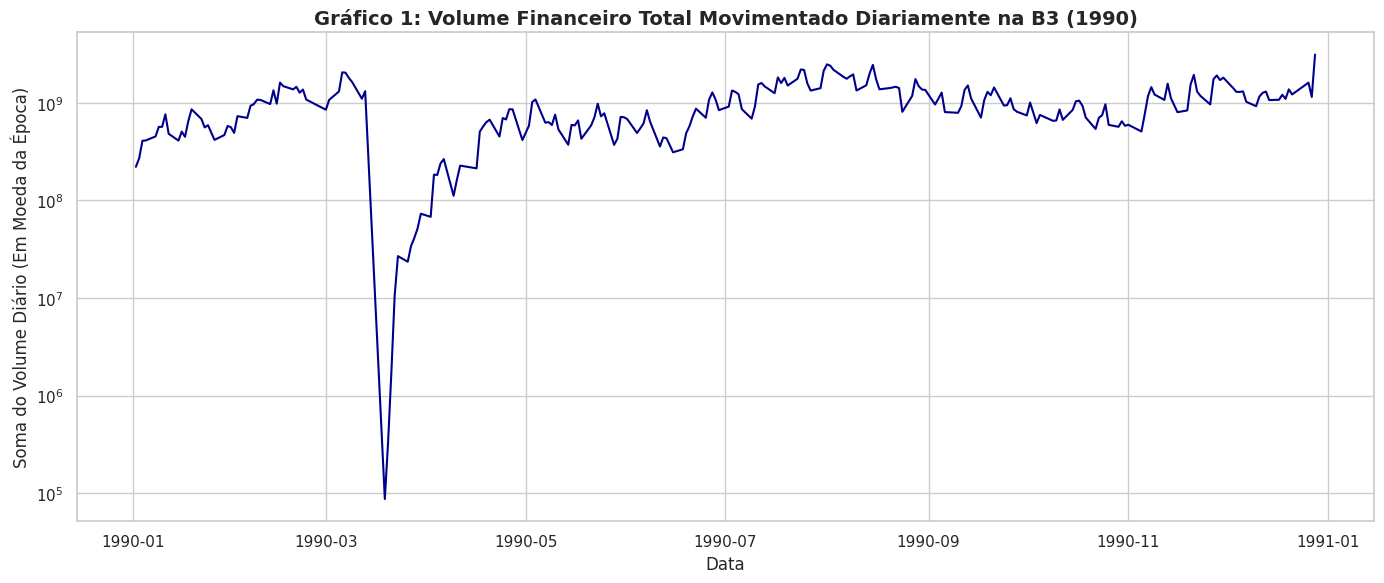

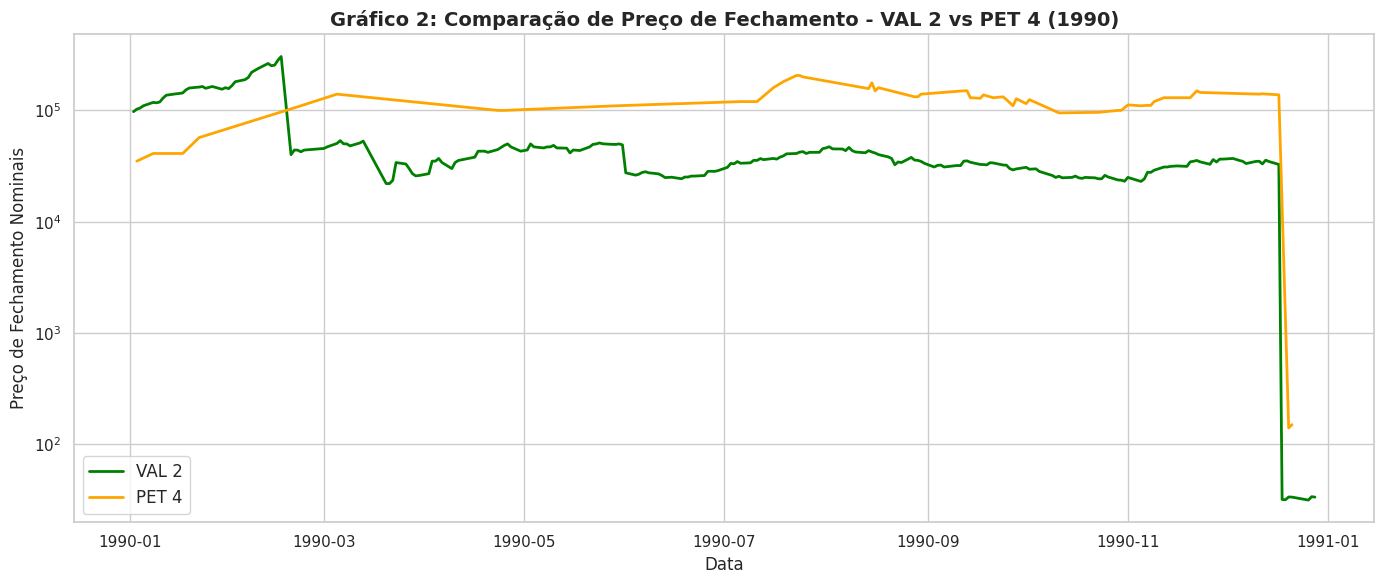

/tmp/ipykernel_577/885879062.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top10, x='ticker', y='volume', palette='viridis')


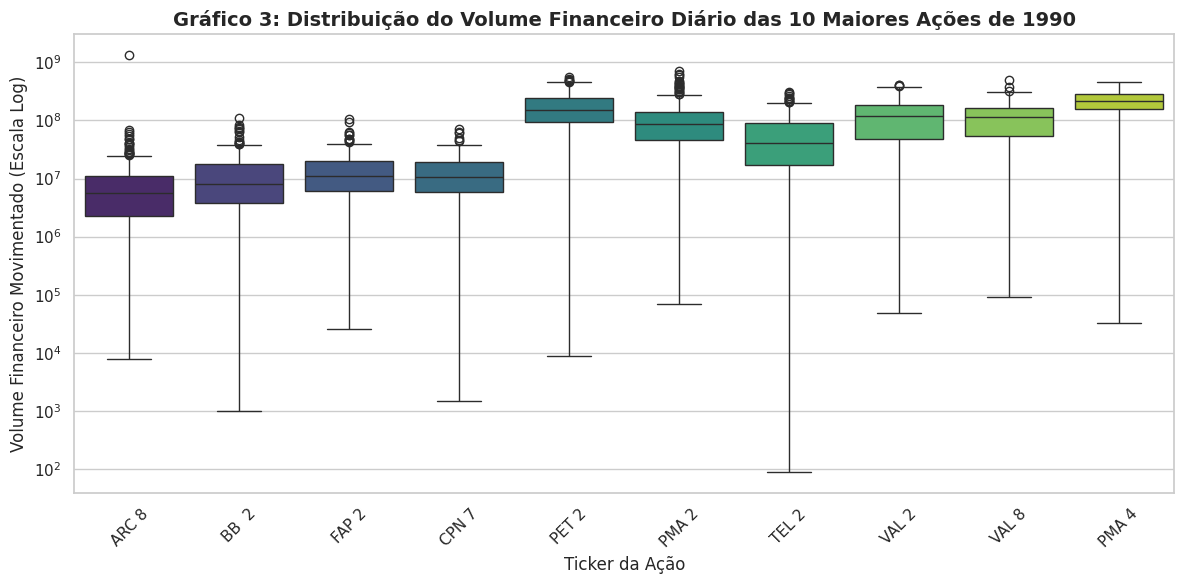

In [26]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- PREPARAÇÃO DOS DADOS ANTES DOS GRÁFICOS ---
# Garantindo que os dados estejam ordenados por data
df_acoes = df_acoes.sort_values('data_pregao')

# Criando uma coluna de Valor Financeiro Diário Movimentado por ativo (se já não for o volume total)
# No COTAHIST, a coluna 'volume' já representa o Volume Financeiro Total do ativo no dia.


# =========================================================================
# GRÁFICO 1: Soma Total do Valor de Mercado (Volume Financeiro Diário da B3)
# =========================================================================
plt.figure(figsize=(14, 6))

# Agrupando por data para somar o volume de todo o mercado naquele dia
volume_diario_mercado = df_acoes.groupby('data_pregao')['volume'].sum().reset_index()

plt.plot(volume_diario_mercado['data_pregao'], volume_diario_mercado['volume'], color='darkblue', linewidth=1.5)
plt.title('Gráfico 1: Volume Financeiro Total Movimentado Diariamente na B3 (1990)', fontsize=14, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Soma do Volume Diário (Em Moeda da Época)', fontsize=12)
plt.yscale('log') # Escala logarítmica recomendada para o ano de 1990 devido à hiperinflação
plt.tight_layout()
plt.show()


# =========================================================================
# GRÁFICO 2: Comparação do Preço de Duas Ações Relevantes
# =========================================================================
plt.figure(figsize=(14, 6))

# Selecionando duas ações muito relevantes no ano de 1990 (Ex: Paranapanema - PMAM4 e Vale - VALE5/VALE3 na época)
# Nota: Adapte os tickers abaixo caso queira olhar outras empresas presentes na sua base
ticker_A = 'VAL 2'
ticker_B = 'PET 4'

df_ativo_A = df_acoes[df_acoes['ticker'] == ticker_A]
df_ativo_B = df_acoes[df_acoes['ticker'] == ticker_B]

plt.plot(df_ativo_A['data_pregao'], df_ativo_A['preco_fechamento'], label=ticker_A, color='green', linewidth=2)
plt.plot(df_ativo_B['data_pregao'], df_ativo_B['preco_fechamento'], label=ticker_B, color='orange', linewidth=2)

plt.title(f'Gráfico 2: Comparação de Preço de Fechamento - {ticker_A} vs {ticker_B} (1990)', fontsize=14, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço de Fechamento Nominais', fontsize=12)
plt.legend(fontsize=12)
plt.yscale('log') # Escala logarítmica essencial para comparar ações na hiperinflação
plt.tight_layout()
plt.show()


# =========================================================================
# GRÁFICO 3: Fator além do preço - Liquidez (Fator de Cotação vs Volume)
# =========================================================================
plt.figure(figsize=(12, 6))

# Para olhar um fator além do preço, vamos analisar o comportamento do Fator de Cotação.
# Em 1990, muitas ações eram cotadas em lotes de 1.000 ou 10.000 ações devido ao valor unitário baixo.
# Vamos cruzar o Fator de Cotação mais frequente com o Volume em um gráfico de barras ou boxplot.

# Selecionando as 10 empresas com maior volume total para entender a distribuição do seu volume diário
top_10_tickers = df_acoes.groupby('ticker')['volume'].sum().nlargest(10).index
df_top10 = df_acoes[df_acoes['ticker'].isin(top_10_tickers)]

sns.boxplot(data=df_top10, x='ticker', y='volume', palette='viridis')
plt.title('Gráfico 3: Distribuição do Volume Financeiro Diário das 10 Maiores Ações de 1990', fontsize=14, fontweight='bold')
plt.xlabel('Ticker da Ação', fontsize=12)
plt.ylabel('Volume Financeiro Movimentado (Escala Log)', fontsize=12)
plt.yscale('log')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Analisando os três gráficos gerados a partir da base de dados, o primeiro destaque marcante é o impacto do **Plano Collor I em março de 1990**, evidenciado pelo Gráfico 1. Vê-se uma queda vertiginosa e abrupta no volume financeiro total negociado na B3, que despencou de um patamar superior a $10^9$ para cerca de $10^5$ (uma retração de mais de $99,9\%$) em questão de dias. Esse colapso de liquidez retrata visualmente o efeito do bloqueio dos ativos financeiros e depósitos bancários decretado pelo governo, paralisando temporariamente os negócios na bolsa até a reestruturação gradual do mercado nos meses subsequentes.

Em segundo lugar, a dinâmica de preços observada no Gráfico 2 revela a forte presença de **ajustes operacionais e eventos corporativos** ao longo do ano. Observa-se que, próximo a dezembro de 1990, os preços nominais das ações da Vale (`VAL 2`) e da Petrobras (`PET 4`) despencam em degraus perfeitamente simultâneos e proporcionais, padrão que também ocorre isoladamente com a Vale em março. Variações bruscas e verticais em múltiplos papéis ao mesmo tempo não indicam perdas de valor real das empresas, mas sim reajustes técnicos típicos do período, como desdobramentos de ações (*splits*), agrupamentos ou alterações no fator de cotação dos lotes negociados.

Por fim, a distribuição retratada no Gráfico 3 escancara uma **alta concentração de liquidez nas *blue chips*** da época. Enquanto um grupo seleto composto por Petrobras, Vale e Paranapanema (`PET 2`, `VAL 2`, `VAL 8`, `PMA 2` e `PMA 4`) manteve seus volumes diários consolidados no topo do gráfico (entre $10^8$ e $10^9$), papéis de menor porte transacionavam rotineiramente em patamares bem mais baixos. Além disso, a presença de *outliers* na parte inferior das caixas — atingindo valores tão baixos quanto $10^2$ — evidencia que a bolsa de 1990 enfrentava dias de extrema volatilidade e seca pontual de liquidez, operando de forma bastante dependente de poucas empresas estatais e exportadoras.